In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Chia dữ liệu
from sklearn.model_selection import train_test_split

# Encode dữ liệu
from sklearn.preprocessing import OneHotEncoder

# Resampling
from sklearn.utils import resample

# Mô hình
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Đánh giá
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

# Vẽ biểu đồ
import matplotlib.pyplot as plt
import seaborn as sns

## Đọc dữ liệu

Mục tiêu:
- Đọc file dữ liệu đã làm sạch
- Kiểm tra nhanh kích thước và kiểu dữ liệu

In [2]:
DATA_PATH = Path("../data/processed/clean_dataset.csv")

df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape[0]:,} dòng × {df.shape[1]} cột")
display(df.head())

# Chuyển về kiểu thời gian nếu cần
df["crash_date"] = pd.to_datetime(df["crash_date"], errors="coerce")

print("\n=== Dtypes ===")

dtype_df = pd.DataFrame({
    "Tên cột": df.columns,
    "Kiểu dữ liệu": df.dtypes.astype(str).values
})

display(dtype_df)

Shape: 209,275 dòng × 24 cột


,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,2023-07-29 13:00:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,2023-08-13 00:11:00,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,2021-12-09 10:30:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,2023-08-09 19:55:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,2023-08-19 14:55:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8



=== Dtypes ===


,Tên cột,Kiểu dữ liệu
0,crash_date,datetime64[ns]
1,traffic_control_device,object
2,weather_condition,object
3,lighting_condition,object
4,first_crash_type,object
5,trafficway_type,object
6,alignment,object
7,roadway_surface_cond,object
8,road_defect,object
9,crash_type,object


## Tạo target 2 class

Mục tiêu:
- Chuyển bài toán về 2 lớp:
  - NO_INJURY: không gây thương tích
  - INJURY: có gây thương tích
- Giúp mô hình phù hợp hơn với dữ liệu hiện có

In [3]:
# Tạo target 2-class
def map_severity(x):
    if x == "NO INDICATION OF INJURY":
        return "NO_INJURY"
    elif x in [
        "REPORTED, NOT EVIDENT",
        "NONINCAPACITATING INJURY",
        "INCAPACITATING INJURY",
        "FATAL"
    ]:
        return "INJURY"
    return "UNKNOWN"

df["severity_label"] = df["most_severe_injury"].apply(map_severity)

# Loại UNKNOWN
before = len(df)
df = df[df["severity_label"] != "UNKNOWN"].copy()

# Thống kê sau
print("\n=== Các target ===")

target_df = df["severity_label"].value_counts().reset_index()
target_df.columns = ["Label", "Count"]
target_df["Tỷ lệ (%)"] = (target_df["Count"] / target_df["Count"].sum() * 100).round(2)

display(target_df)


=== Các target ===


,Label,Count,Tỷ lệ (%)
0,NO_INJURY,154767,73.95
1,INJURY,54508,26.05


## Chọn biến đầu vào

Mục tiêu:
- Giữ các biến có thể dùng để dự báo
- Loại bỏ các biến gây rò rỉ thông tin hoặc quá gần với target

In [4]:
drop_cols = [
    "most_severe_injury",
    "injuries_total",
    "injuries_fatal",
    "injuries_incapacitating",
    "injuries_non_incapacitating",
    "injuries_reported_not_evident",
    "injuries_no_indication",
    "crash_type",
    "damage",
    "crash_date"
]

df_model = df.drop(columns=drop_cols)

target_col = "severity_label"

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print(f"Số feature: {X.shape[1]}")
print(f"Số mẫu: {X.shape[0]:,}")

# ===== Feature bị loại =====
print("\n=== Feature bị loại ===")
feature_drop_df = pd.DataFrame({
    "Tên feature": sorted(drop_cols)
})
display(feature_drop_df)

# ===== Feature được chọn =====
print("\n=== Feature đầu vào (được giữ lại) ===")
feature_keep_df = pd.DataFrame({
    "Tên feature": sorted(X.columns)
})
display(feature_keep_df)


Số feature: 14
Số mẫu: 209,275

=== Feature bị loại ===


,Tên feature
0,crash_date
1,crash_type
2,damage
3,injuries_fatal
4,injuries_incapacitating
5,injuries_no_indication
6,injuries_non_incapacitating
7,injuries_reported_not_evident
8,injuries_total
9,most_severe_injury



=== Feature đầu vào (được giữ lại) ===


,Tên feature
0,alignment
1,crash_day_of_week
2,crash_hour
3,crash_month
4,first_crash_type
5,intersection_related_i
6,lighting_condition
7,num_units
8,prim_contributory_cause
9,road_defect


## Phân tích mối liên hệ giữa các biến phân loại

Mục tiêu:
- Kiểm tra mức độ liên hệ giữa các biến categorical trước khi encode
- Hỗ trợ giải thích việc lựa chọn feature
- Tránh dùng heatmap Pearson trên dữ liệu one-hot vì khó diễn giải

In [5]:
# Chỉ lấy các cột categorical gốc đã được giữ lại
cat_cols_eda = X.select_dtypes(include="object").columns.tolist()

print("=== Các cột categorical dùng cho Cramer's V ===")
print(f"Số cột: {len(cat_cols_eda)}")

cat_eda_df = pd.DataFrame({"Categorical feature": sorted(cat_cols_eda)})
display(cat_eda_df)

=== Các cột categorical dùng cho Cramer's V ===
Số cột: 9


,Categorical feature
0,alignment
1,first_crash_type
2,lighting_condition
3,prim_contributory_cause
4,road_defect
5,roadway_surface_cond
6,traffic_control_device
7,trafficway_type
8,weather_condition


In [ ]:
# Tính ma trận Cramer’s V
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """
    Tính Cramer's V cho hai biến categorical.
    Có dùng hiệu chỉnh nhẹ để kết quả ổn định hơn.
    """
    confusion_matrix = pd.crosstab(x, y)

    if confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
        return np.nan

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()

    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # Bias correction
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return np.nan

    return np.sqrt(phi2corr / denom)

# Tạo ma trận Cramer's V
cramers_v_matrix = pd.DataFrame(
    np.zeros((len(cat_cols_eda), len(cat_cols_eda))),
    index=cat_cols_eda,
    columns=cat_cols_eda
)

for col1 in cat_cols_eda:
    for col2 in cat_cols_eda:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(df_model[col1], df_model[col2])

print("=== Ma trận Cramer's V ===")
display(cramers_v_matrix.round(3))

=== Ma trận Cramer's V ===


,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,prim_contributory_cause
traffic_control_device,1.000,0.077,0.127,0.112,0.072,0.015,0.100,0.095,0.112
weather_condition,0.077,1.000,0.298,0.030,0.036,0.014,0.505,0.137,0.099
lighting_condition,0.127,0.298,1.000,0.050,0.061,0.008,0.225,0.126,0.083
first_crash_type,0.112,0.030,0.050,1.000,0.072,0.031,0.047,0.075,0.259
trafficway_type,0.072,0.036,0.061,0.072,1.000,0.057,0.047,0.045,0.057
alignment,0.015,0.014,0.008,0.031,0.057,1.000,0.016,0.018,0.034
roadway_surface_cond,0.100,0.505,0.225,0.047,0.047,0.016,1.000,0.217,0.154
road_defect,0.095,0.137,0.126,0.075,0.045,0.018,0.217,1.000,0.135
prim_contributory_cause,0.112,0.099,0.083,0.259,0.057,0.034,0.154,0.135,1.000


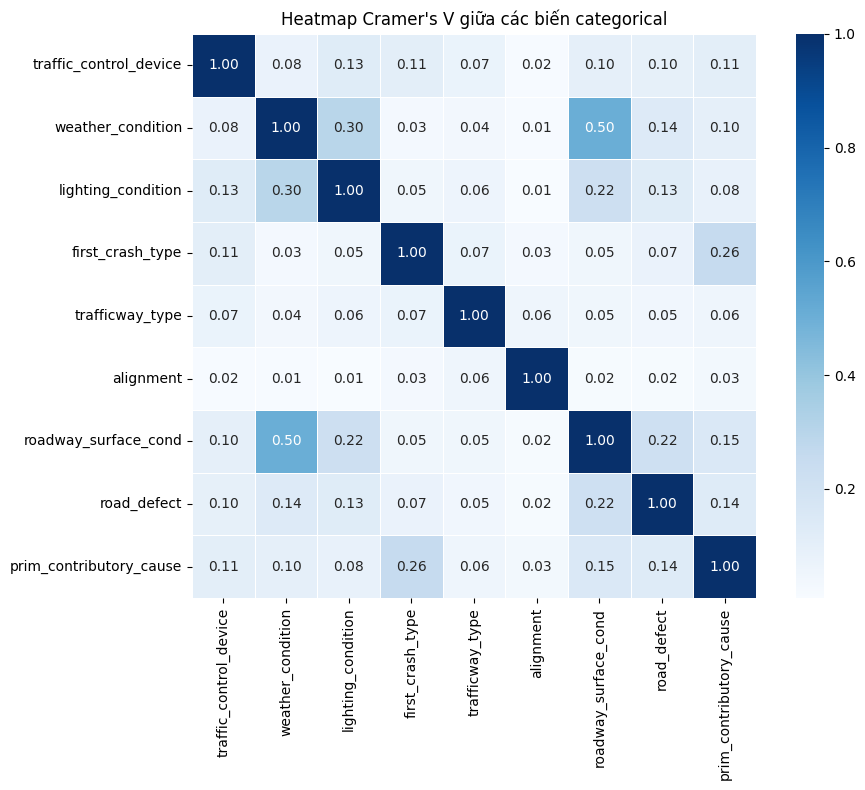

In [ ]:
# Vẽ heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cramers_v_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    square=True,
    linewidths=0.5
)

plt.title("Heatmap Cramer's V giữa các biến categorical")
plt.tight_layout()
plt.show()

## Liệt kê các cặp biến có mức liên hệ cao

Mục tiêu:
- Xác định những cặp biến có liên hệ mạnh
- Làm cơ sở để giải thích việc giữ hoặc loại feature

In [8]:
# Lấy các cặp biến ở nửa trên ma trận để tránh lặp
pairs = []

for i in range(len(cat_cols_eda)):
    for j in range(i + 1, len(cat_cols_eda)):
        col1 = cat_cols_eda[i]
        col2 = cat_cols_eda[j]
        value = cramers_v_matrix.loc[col1, col2]
        pairs.append((col1, col2, value))

cramers_pairs_df = pd.DataFrame(
    pairs,
    columns=["Feature 1", "Feature 2", "Cramers_V"]
).sort_values(by="Cramers_V", ascending=False).reset_index(drop=True)

print("=== Top cặp biến categorical có liên hệ cao ===")
display(cramers_pairs_df.head(10))

=== Top cặp biến categorical có liên hệ cao ===


,Feature 1,Feature 2,Cramers_V
0,weather_condition,roadway_surface_cond,0.504788
1,weather_condition,lighting_condition,0.298232
2,first_crash_type,prim_contributory_cause,0.258721
3,lighting_condition,roadway_surface_cond,0.224599
4,roadway_surface_cond,road_defect,0.216745
5,roadway_surface_cond,prim_contributory_cause,0.154376
6,weather_condition,road_defect,0.137065
7,road_defect,prim_contributory_cause,0.135278
8,traffic_control_device,lighting_condition,0.126535
9,lighting_condition,road_defect,0.126279


## Chia dữ liệu

Mục tiêu:
- Chia dữ liệu theo tỷ lệ 80/20
- Dùng `stratify` để giữ tỷ lệ lớp giữa train và test

In [5]:
# Chia dữ liệu train/test (80/20, giữ tỷ lệ lớp)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Kích thước dữ liệu
print("=== Kích thước dữ liệu ===")
print(f"Train: {X_train.shape[0]:,} mẫu × {X_train.shape[1]} feature")
print(f"Test:  {X_test.shape[0]:,} mẫu × {X_test.shape[1]} feature")

# Hàm hiển thị
def show_distribution(y_data, name):
    dist = y_data.value_counts().reset_index()
    dist.columns = ["Label", "Count"]

    print(f"\n=== Phân bố target trong {name} ===")
    display(dist)

# Hiển thị phân bố
show_distribution(y_train, "train")
show_distribution(y_test, "test")

=== Kích thước dữ liệu ===
Train: 167,420 mẫu × 14 feature
Test:  41,855 mẫu × 14 feature

=== Phân bố target trong train ===


,Label,Count
0,NO_INJURY,123814
1,INJURY,43606



=== Phân bố target trong test ===


,Label,Count
0,NO_INJURY,30953
1,INJURY,10902


## Cân bằng dữ liệu trên tập train

Mục tiêu:
- Chỉ cân bằng trên train để tránh làm sai lệch việc đánh giá
- Giảm bớt lớp lớn `NO_INJURY` để mô hình học tốt hơn lớp `INJURY`

In [6]:
# Ghép X_train và y_train để resample thuận tiện 
train_df = X_train.copy()
train_df[target_col] = y_train.values

df_no = train_df[train_df[target_col] == "NO_INJURY"]
df_injury = train_df[train_df[target_col] == "INJURY"]

# Hàm hiển thị phân bố
def show_dist(data, name):
    dist = data.value_counts().reset_index()
    dist.columns = ["Label", "Count"]
    dist["Tỷ lệ (%)"] = (dist["Count"] / dist["Count"].sum() * 100).round(2)
    print(f"\n=== {name} ===")
    display(dist)

# Trước cân bằng
show_dist(train_df[target_col], "Phân bố trước cân bằng")

# Cân bằng mềm: giữ NO_INJURY ≈ 1.1 * INJURY
injury_count = len(df_injury)
target_no = min(int(injury_count * 1.1), len(df_no))

df_no_down = resample(
    df_no,
    replace=False,
    n_samples=target_no,
    random_state=42
)

train_balanced = pd.concat([df_no_down, df_injury], axis=0)
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Sau cân bằng
show_dist(train_balanced[target_col], "Phân bố sau cân bằng")


=== Phân bố trước cân bằng ===


,Label,Count,Tỷ lệ (%)
0,NO_INJURY,123814,73.95
1,INJURY,43606,26.05



=== Phân bố sau cân bằng ===


,Label,Count,Tỷ lệ (%)
0,NO_INJURY,47966,52.38
1,INJURY,43606,47.62


## Tách lại tập train sau cân bằng

Mục tiêu:
- Tạo lại tập train sau khi resample
- Chuẩn bị cho bước encode

In [13]:
X_train_bal = train_balanced.drop(columns=[target_col])
y_train_bal = train_balanced[target_col]

print("=== Kích thước sau cân bằng ===")
print(f"X_train_bal: {X_train_bal.shape[0]:,} mẫu × {X_train_bal.shape[1]} feature")
print(f"y_train_bal: {y_train_bal.shape[0]:,} nhãn")

=== Kích thước sau cân bằng ===
X_train_bal: 91,572 mẫu × 14 feature
y_train_bal: 91,572 nhãn


## Encode dữ liệu

Mục tiêu:
- One-hot encoding cho các biến phân loại
- Giữ nguyên các biến số

In [14]:
# Xác định cột categorical và numeric
categorical_cols = X_train_bal.select_dtypes(include="object").columns.tolist()
numeric_cols = X_train_bal.select_dtypes(exclude="object").columns.tolist()

print("=== Phân loại feature ===")
print(f"Số cột categorical: {len(categorical_cols)}")
print(f"Số cột numeric: {len(numeric_cols)}")

# Hiển thị bảng
cat_df = pd.DataFrame({"Categorical feature": sorted(categorical_cols)})
num_df = pd.DataFrame({"Numeric feature": sorted(numeric_cols)})

print("\nDanh sách categorical:")
display(cat_df)

print("Danh sách numeric:")
display(num_df)

=== Phân loại feature ===
Số cột categorical: 9
Số cột numeric: 5

Danh sách categorical:


,Categorical feature
0,alignment
1,first_crash_type
2,lighting_condition
3,prim_contributory_cause
4,road_defect
5,roadway_surface_cond
6,traffic_control_device
7,trafficway_type
8,weather_condition


Danh sách numeric:


,Numeric feature
0,crash_day_of_week
1,crash_hour
2,crash_month
3,intersection_related_i
4,num_units


In [15]:
# One-hot encoding
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train_bal[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

encoded_feature_names = encoder.get_feature_names_out(categorical_cols)

print("=== Encoding ===")
print(f"Số feature categorical ban đầu: {len(categorical_cols)}")
print(f"Số feature sau encode: {len(encoded_feature_names):,}")

=== Encoding ===
Số feature categorical ban đầu: 9
Số feature sau encode: 132


In [16]:
# Ghép lại dữ liệu sau encode
X_train_cat_df = pd.DataFrame(
    X_train_cat,
    columns=encoded_feature_names,
    index=X_train_bal.index
)

X_test_cat_df = pd.DataFrame(
    X_test_cat,
    columns=encoded_feature_names,
    index=X_test.index
)

X_train_final = pd.concat(
    [X_train_bal[numeric_cols].reset_index(drop=True), 
     X_train_cat_df.reset_index(drop=True)],
    axis=1
)

X_test_final = pd.concat(
    [X_test[numeric_cols].reset_index(drop=True), 
     X_test_cat_df.reset_index(drop=True)],
    axis=1
)

print("=== Dữ liệu sau xử lý ===")
print(f"Train: {X_train_final.shape[0]:,} mẫu × {X_train_final.shape[1]} feature")
print(f"Test:  {X_test_final.shape[0]:,} mẫu × {X_test_final.shape[1]} feature")

=== Dữ liệu sau xử lý ===
Train: 91,572 mẫu × 137 feature
Test:  41,855 mẫu × 137 feature


## Huấn luyện mô hình

Mục tiêu:
- Sử dụng hai mô hình gồm Decision Tree và Random Forest
- So sánh kết quả để chọn mô hình phù hợp hơn cho việc rút insight

## Huấn luyện Decision Tree

In [19]:
# Khởi tạo mô hình
dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight=None,
    random_state=42
)

In [20]:
# Huấn luyện mô hình và dự đoán
dt_model.fit(X_train_final, y_train_bal)

y_pred_dt = dt_model.predict(X_test_final)

## Đánh giá mô hình Decision Tree

In [21]:
acc_dt = accuracy_score(y_test, y_pred_dt)
macro_f1_dt = f1_score(y_test, y_pred_dt, average="macro")

print("=== Decision Tree ===")

# Hiển thị metric dạng bảng
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro F1"],
    "Value": [round(acc_dt, 4), round(macro_f1_dt, 4)]
})

display(metrics_df)

# Classification report dạng bảng
report = classification_report(y_test, y_pred_dt, output_dict=True)
report_df = pd.DataFrame(report).transpose().round(3)

print("\n=== Classification Report ===")
display(report_df)

=== Decision Tree ===


,Metric,Value
0,Accuracy,0.7372
1,Macro F1,0.6629



=== Classification Report ===


,precision,recall,f1-score,support
INJURY,0.496,0.514,0.505,10902.000
NO_INJURY,0.826,0.816,0.821,30953.000
accuracy,0.737,0.737,0.737,0.737
macro avg,0.661,0.665,0.663,41855.000
weighted avg,0.740,0.737,0.739,41855.000


## Huấn luyện Random Forest

In [22]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [23]:
# Huấn luyện mô hình và dự đoán
rf_model.fit(X_train_final, y_train_bal)

y_pred_rf = rf_model.predict(X_test_final)

## Đánh giá mô hình Random Forest

In [24]:
acc_rf = accuracy_score(y_test, y_pred_rf)
macro_f1_rf = f1_score(y_test, y_pred_rf, average="macro")

print("=== Random Forest ===")

metrics_rf_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro F1"],
    "Value": [round(acc_rf, 4), round(macro_f1_rf, 4)]
})

display(metrics_rf_df)

report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
report_rf_df = pd.DataFrame(report_rf).transpose().round(3)

print("\n=== Classification Report ===")
display(report_rf_df)

=== Random Forest ===


,Metric,Value
0,Accuracy,0.7311
1,Macro F1,0.6677



=== Classification Report ===


,precision,recall,f1-score,support
INJURY,0.486,0.565,0.523,10902.000
NO_INJURY,0.838,0.789,0.813,30953.000
accuracy,0.731,0.731,0.731,0.731
macro avg,0.662,0.677,0.668,41855.000
weighted avg,0.746,0.731,0.737,41855.000


## Ma trận nhầm lẫn

Mục tiêu:
- Quan sát mô hình dự đoán nhầm giữa hai lớp như thế nào
- Kiểm tra mô hình có đang thiên lệch về lớp đa số hay không

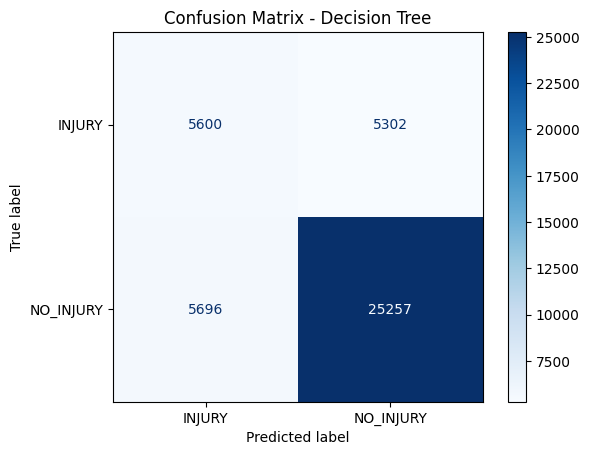

In [26]:
# Ma trận nhầm lẫn cho Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=dt_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=dt_model.classes_
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

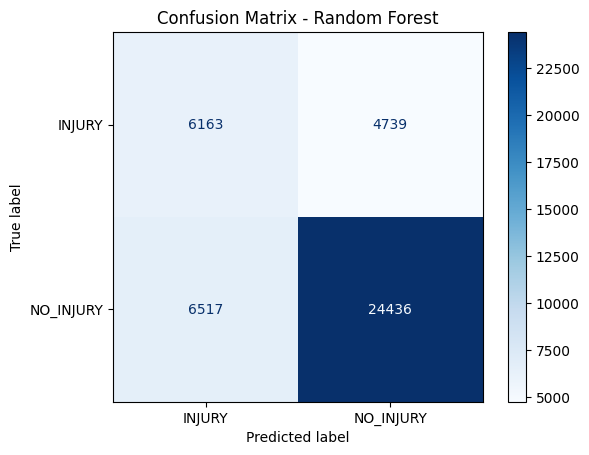

In [28]:
# Ma trận nhầm lẫn cho Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=rf_model.classes_
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

## So sánh 2 mô hình

In [30]:
f1_dt_injury = report_df.loc["INJURY", "f1-score"]
f1_rf_injury = report_rf_df.loc["INJURY", "f1-score"]

results_compare = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [round(acc_dt, 4), round(acc_rf, 4)],
    "Macro F1": [round(macro_f1_dt, 4), round(macro_f1_rf, 4)],
    "F1 (INJURY)": [round(f1_dt_injury, 4), round(f1_rf_injury, 4)]
})

display(results_compare)

,Model,Accuracy,Macro F1,F1 (INJURY)
0,Decision Tree,0.7372,0.6629,0.505
1,Random Forest,0.7311,0.6677,0.523


## Lựa chọn mô hình

- Random Forest có Accuracy và Macro F1 cao hơn Decision Tree
- Khả năng phân loại ổn định hơn (qua confusion matrix)

### Ưu tiên Recall của lớp INJURY

- False Negative (FN): dự đoán NO_INJURY nhưng thực tế là INJURY → nguy hiểm, dễ bỏ sót tai nạn cần can thiệp
- False Positive (FP): dự đoán INJURY nhưng thực tế không → chỉ gây cảnh báo nhầm

→ Trong bài toán này, ưu tiên Recall của lớp INJURY để giảm rủi ro bỏ sót

### Kết luận

Chọn Random Forest làm mô hình chính vì:
- hiệu quả tốt hơn
- ổn định hơn
- phù hợp với mục tiêu phát hiện tai nạn có thương tích

## Độ quan trọng của đặc trưng

Mục tiêu:
- Xác định các biến có ảnh hưởng nhiều nhất đến kết quả phân loại
- Làm cơ sở để rút ra insight thực tiễn

In [31]:
feature_importance_df = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

top_features = feature_importance_df.head(15)

print("=== Top 15 feature quan trọng nhất ===")
display(top_features)

=== Top 15 feature quan trọng nhất ===


,Feature,Importance
0,first_crash_type_PEDESTRIAN,0.262240
1,first_crash_type_SIDESWIPE SAME DIRECTION,0.111084
2,first_crash_type_PEDALCYCLIST,0.106033
3,num_units,0.067201
4,first_crash_type_REAR END,0.045227
5,prim_contributory_cause_DISREGARDING TRAFFIC S...,0.037821
6,first_crash_type_ANGLE,0.033102
7,first_crash_type_TURNING,0.033030
8,prim_contributory_cause_FAILING TO YIELD RIGHT...,0.029394
9,prim_contributory_cause_FOLLOWING TOO CLOSELY,0.024456


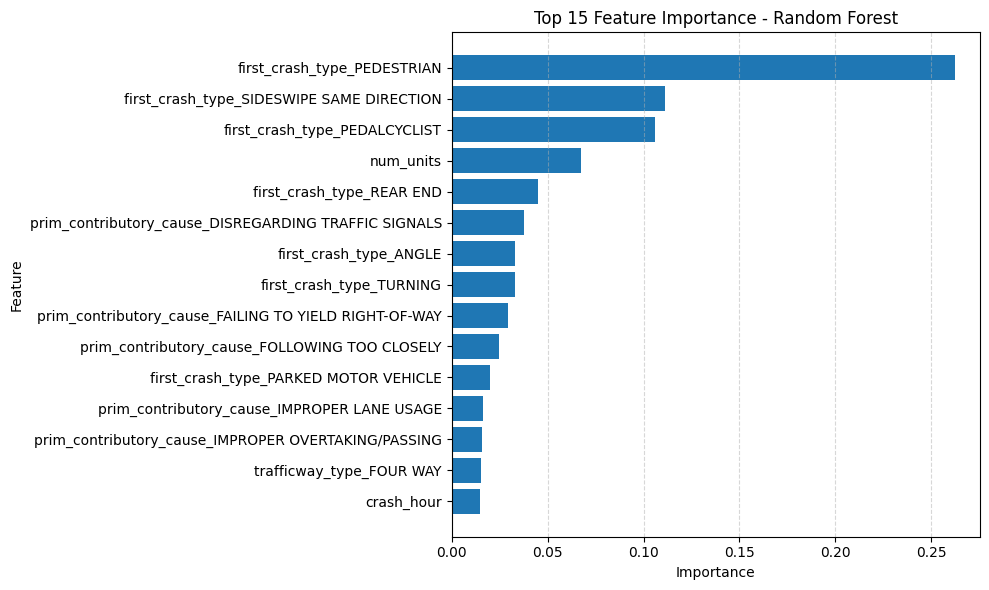

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(top_features["Feature"], top_features["Importance"])

plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

=== Feature importance theo nhóm ===


,Group,Importance
0,first_crash_type,0.618433
1,prim_contributory_cause,0.169809
2,num_units,0.067201
3,trafficway_type,0.033128
4,roadway_surface_cond,0.018585
5,traffic_control_device,0.017244
6,lighting_condition,0.016130
7,weather_condition,0.015554
8,crash_hour,0.014724
9,crash_month,0.010537


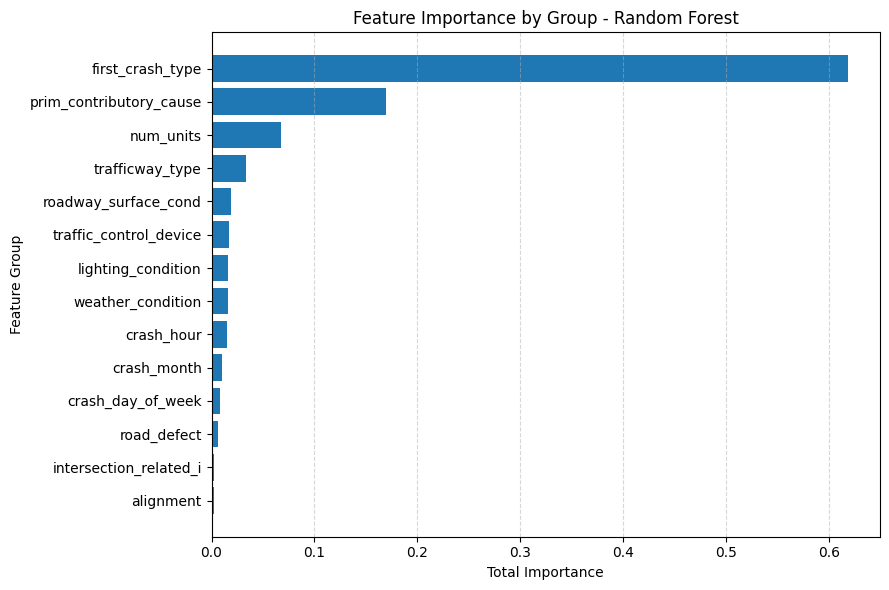

In [38]:
# Gộp feature importance theo nhóm và vẽ biểu đồ
def map_feature_group(feature_name):
    if feature_name.startswith("traffic_control_device_"):
        return "traffic_control_device"
    elif feature_name.startswith("weather_condition_"):
        return "weather_condition"
    elif feature_name.startswith("lighting_condition_"):
        return "lighting_condition"
    elif feature_name.startswith("first_crash_type_"):
        return "first_crash_type"
    elif feature_name.startswith("trafficway_type_"):
        return "trafficway_type"
    elif feature_name.startswith("alignment_"):
        return "alignment"
    elif feature_name.startswith("roadway_surface_cond_"):
        return "roadway_surface_cond"
    elif feature_name.startswith("road_defect_"):
        return "road_defect"
    elif feature_name.startswith("intersection_related_i"):
        return "intersection_related_i"
    elif feature_name.startswith("prim_contributory_cause_"):
        return "prim_contributory_cause"
    elif feature_name.startswith("num_units"):
        return "num_units"
    elif feature_name.startswith("crash_hour"):
        return "crash_hour"
    elif feature_name.startswith("crash_day_of_week"):
        return "crash_day_of_week"
    elif feature_name.startswith("crash_month"):
        return "crash_month"
    else:
        return "other"

group_summary = (
    feature_importance_df.assign(
        Group=feature_importance_df["Feature"].apply(map_feature_group)
    )
    .groupby("Group", as_index=False)["Importance"]
    .sum()
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

print("=== Feature importance theo nhóm ===")
display(group_summary)

plt.figure(figsize=(9, 6))
plt.barh(group_summary["Group"], group_summary["Importance"])

plt.title("Feature Importance by Group - Random Forest")
plt.xlabel("Total Importance")
plt.ylabel("Feature Group")

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Kết luận ngắn

Mô hình Random Forest được xây dựng để dự đoán khả năng tai nạn giao thông có gây thương tích hay không theo bài toán 2 class.

Việc chuyển từ 3 class sang 2 class giúp bài toán phù hợp hơn với dữ liệu hiện có, do các biến trong dataset chủ yếu phản ánh hành vi, môi trường và hạ tầng, nhưng chưa đủ mạnh để phân biệt rõ giữa chấn thương nhẹ và chấn thương nặng.

Kết quả của mô hình sẽ được dùng để rút ra insight về:
- vai trò của hành vi người lái
- tác động của môi trường
- ảnh hưởng của hạ tầng giao thông
- khả năng ứng dụng trong thực tế như vận tải, bảo hiểm và quản lý an toàn giao thông